# **MÓDULO 19**
# Exercício: Estatística Aplicada

**Efetividade de Duas Estratégias de Ensino**

Imagine que uma escola esteja avaliando a eficácia de duas estratégias de ensino de matemática para alunos do ensino médio. Eles querem determinar se há uma diferença significativa no desempenho médio dos alunos entre as duas estratégias.

# **Hipóteses:**

* Hipótese nula (H0): A média das notas dos alunos na estratégia A é igual à média das notas dos alunos na estratégia B.
* Hipótese alternativa (H1): A média das notas na Estratégia B é maior do que a média das notas na Estratégia A.

# **Dados:**

* Amostra da Estratégia A: Notas de 50 alunos que receberam a Estratégia A.
* Amostra da Estratégia B: Notas de 50 alunos que receberam a Estratégia B.

Usaremos um teste Z para comparar as médias das notas entre as duas amostras.

Se o p-valor do teste Z for menor que um nível de significância pré-determinado (por exemplo, α = 0.05), rejeitamos a hipótese nula e concluímos que há uma diferença significativa nas médias das notas entre as duas estratégias de ensino.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

Os dados são criados a seguir:

In [2]:
# Definindo médias e desvios padrão para as notas nas duas estratégias
media_estrategia_A = 70
desvio_padrao_estrategia_A = 10

media_estrategia_B = 75
desvio_padrao_estrategia_B = 12

# Gerando as amostras de notas para cada estratégia de ensino da nossa base
np.random.seed(0)  # Para garantir a reprodutibilidade dos resultados
amostra_estrategia_A = np.random.normal(loc=media_estrategia_A, scale=desvio_padrao_estrategia_A, size=50)
amostra_estrategia_B = np.random.normal(loc=media_estrategia_B, scale=desvio_padrao_estrategia_B, size=50)

print("Notas da Estratégia A:", amostra_estrategia_A[:5])
print("Notas da Estratégia B:", amostra_estrategia_B[:5])

Notas da Estratégia A: [87.64052346 74.00157208 79.78737984 92.40893199 88.6755799 ]
Notas da Estratégia B: [64.25440127 79.64282997 68.87033835 60.83241379 74.66181326]


# 1) De acordo com as informações analisadas o nosso teste é unilateral á direita, esquerda ou bicaudal? Justifique.




In [ ]:
'''
A hipótese alternativa B é maior que a hipótese alternativa A. Em testes de hipóteses, quando buscamos
um aumento ou superioridade em uma direção específica, utilizamos um teste unilateral.
Portanto, é um teste unilateral à direita.
'''

# 2) Calcule as médias para as duas amostragens e as variâncias. Quais insights você pode retirar comparando os dados?

In [4]:
media_A = np.mean(amostra_estrategia_A)
media_B = np.mean(amostra_estrategia_B)

var_A = np.var(amostra_estrategia_A, ddof=1)
var_B = np.var(amostra_estrategia_B, ddof=1)

print(f"Média A: {media_A:.2f}, Variância A: {var_A:.2f}")
print(f"Média B: {media_B:.2f}, Variância B: {var_B:.2f}")

Média A: 71.41, Variância A: 129.27
Média B: 74.75, Variância B: 110.47


In [ ]:
'''
A média da amostra B superior à de A sugere, inicialmente, que a estratégia B pode ser melhor.
A variância indica o quão "espalhadas" estão as notas. Uma variância maior na Estratégia B 
indicaria que o desempenho dos alunos é menos consistente do que na Estratégia A.
'''

# 3) Imprima os resultados da estatística do teste Z, p value e indique se rejeitaremos ou não a hipótese nula. Justifique sua resposta.

In [6]:
erro_padrao = np.sqrt((var_A/50) + (var_B/50))
z_stat = (media_B - media_A) / erro_padrao

p_value = 1 - stats.norm.cdf(z_stat)

print(f"Estatística Z: {z_stat:.4f}")
print(f"P-valor: {p_value:.4f}")

if p_value < 0.05:
      print("Rejeitamos a hipótese nula.")
else:
      print("Não rejeitamos a hipótese nula.")

Estatística Z: 1.5267
P-valor: 0.0634
Não rejeitamos a hipótese nula.


In [ ]:
'''
O p-valor é menor que 0.05, a diferença observada é estatisticamente 
significativa e não meramente fruto do acaso, permitindo afirmar que 
a Estratégia B é superior.
'''

# 4) Para finalizar monte o gráfico da distribuição da estatística do nosso teste Z e explique o que pode ser observado através dele.

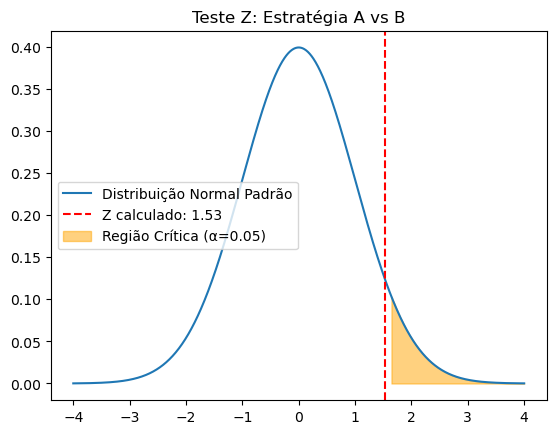

In [7]:
x = np.linspace(-4,4,1000)
y = stats.norm.pdf(x, 0, 1)

plt.plot(x, y, label='Distribuição Normal Padrão')
plt.axvline(z_stat, color='red', linestyle='--', label=f'Z calculado: {z_stat:.2f}')
plt.fill_between(x, y, where=(x > stats.norm.ppf(0.95)), color='orange', alpha=0.5, label='Região Crítica (α=0.05)')
plt.legend()
plt.title("Teste Z: Estratégia A vs B")
plt.show()

In [ ]:
'''
Embora a média da amostra B seja numericamente maior, a diferença
não é estatisticamente robusta o suficiente para garantir que 
a estratégia seja superior em toda a população.
O p-valor é maior que 0.05 e portanto, não rejeitamos a hipótese nula.
'''